In [2]:
!pip install python-dotenv langchain-huggingface huggingface_hub

In [3]:
import os
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

# Step 1: Load environment variables from .env file
load_dotenv()

# Step 2: Verify API Key is loaded
api_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

In [4]:
!pip install langgraph

In [5]:
!pip install google-genai

  Using cached google_genai-2.21.0-py3-none-any.whl.metadata (56 kB)
  Using cached google_auth-2.57.0-py3-none-any.whl.metadata (6.0 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached cryptography-50.0.1-cp311-abi3-win_amd64.whl.metadata (4.3 kB)
  Using cached cffi-2.1.1-cp311-cp311-win_amd64.whl.metadata (2.6 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached pyasn1-0.6.4-py3-none-any.whl.metadata (8.4 kB)
Using cached google_genai-2.21.0-py3-none-any.whl (1.1 MB)
Using cached google_auth-2.57.0-py3-none-any.whl (259 kB)
Using cached cryptography-50.0.1-cp311-abi3-win_amd64.whl (3.8 MB)
Using cached cffi-2.1.1-cp311-cp311-win_amd64.whl (185 kB)
Using cached pyasn1_modules-0.4.2-py3-none-any.whl (181 kB)
Using cached pyasn1-0.6.4-py3-none-any.whl (84 kB)
Using cached pycparser-3.0-py3-none-any.whl (48 kB)

   ---------------------------------------- 0/7 [pycparser]
   ---------------------------------------- 0/7 [

In [6]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
import operator
from langchain_core.messages import SystemMessage, HumanMessage
import json

In [7]:
class Blog(TypedDict):
    topic: str
    needs_research: bool
    research: str
    content: str
    needs_image: bool
    image_prompt: str
    image_path: str

In [8]:
def research_decision(state: Blog):
    topic = state["topic"]

    # Temporary logic just for understanding the graph
    if "latest" in topic.lower() or "current" in topic.lower():
        return {"needs_research": True}

    return {"needs_research": False}

In [9]:
from pydantic import BaseModel, Field

# this is pydantic model for the output of the image decision node
class ImageDecision(BaseModel):
    needs_image: bool = Field(
        description="Whether the blog would benefit from an image"
    )

    image_prompt: str = Field(
        description="A detailed prompt for generating the image. "
                    "Empty if no image is needed."
    )

    reason: str = Field(
        description="Why an image is or is not useful"
    )

In [10]:
def route_research(state: Blog):
    if state["needs_research"]:
        return "research"

    return "generate-content"

In [26]:
def generate_content(state: Blog) -> Blog:
    title = state["topic"]
    api_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

    llm = HuggingFaceEndpoint(
        repo_id="meta-llama/Llama-3.1-8B-Instruct",
        task="conversational",  # <-- Explicitly set the task expected by the provider
        max_new_tokens=512,
        huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN")
    )

    chat_model = ChatHuggingFace(llm=llm)


    response = chat_model.invoke(f"Write a blog post about '{title}'.")
    return {
    "topic": title,
    "content": response.content,
}

In [25]:
def image_decision(state: Blog):
    content = state["content"]

    llm = HuggingFaceEndpoint(
        repo_id="meta-llama/Llama-3.1-8B-Instruct",
        task="conversational",
        max_new_tokens=256,
        huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"),
    )

    chat_model = ChatHuggingFace(llm=llm)

    prompt = f"""
Decide whether this blog post needs an image.

Blog post:
{content}

Return only valid JSON:
{{
  "needs_image": true,
  "image_prompt": "a detailed image prompt"
}}
"""

    response = chat_model.invoke(prompt)

    decision = json.loads(response.content)

    return {
        "needs_image": decision["needs_image"],
        "image_prompt": decision["image_prompt"],
    }

In [28]:
import os
from huggingface_hub import InferenceClient
from dotenv import load_dotenv

load_dotenv()

# Initialize Hugging Face client
hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

client = InferenceClient(token=hf_token)


def generate_image_from_api(
    prompt: str,
    output_path: str = "blog_banner.png"
) -> str:
    """
    Generate an image using Hugging Face FLUX model
    and save it locally.
    """

    try:
        image = client.text_to_image(
            prompt=prompt,
            model="black-forest-labs/FLUX.1-schnell"
        )

        # Save generated image
        image.save(output_path)

        print(f"Image successfully saved to {output_path}")

        return output_path

    except Exception as e:
        print(f"Image generation failed: {e}")
        raise


def generate_image(state: Blog):
    """
    LangGraph node that generates a blog image.
    """

    prompt = state["image_prompt"]

    image_path = generate_image_from_api(
        prompt=prompt,
        output_path="blog_picture.png"
    )

    return {
        "image_path": image_path
    }

In [29]:
def insert_image(state: Blog):
    content = state["content"]
    image_path = state["image_path"]

    updated_content = content + f"\n\n![Blog Image]({image_path})\n"

    return {
        "content": updated_content
    }

In [34]:
from langgraph.graph import END


def route_image(state: Blog):

    if state["needs_image"]:
        return "generate_image"

    return END

In [30]:
graph = StateGraph(Blog)

graph.add_node('generate-content', generate_content)
graph.add_node('research_decision', research_decision)
graph.add_node('research', route_research)
graph.add_node('image_decision', image_decision)
# graph.add_node()
graph.add_node('generate_image', generate_image)
graph.add_node('insert_image', insert_image)

graph.add_edge(START, 'research_decision')
graph.add_conditional_edges("research_decision", route_research, {
    "research": "research",
    "generate-content": "generate-content"
})
graph.add_edge('research_decision', 'generate-content')
graph.add_edge('research', 'generate-content')
graph.add_edge('generate-content', 'image_decision')
graph.add_conditional_edges("image_decision", route_image, {
    "generate_image": "generate_image",
    END: END
})
graph.add_edge('generate_image', 'insert_image')
graph.add_edge('insert_image', END)
blog=graph.compile()

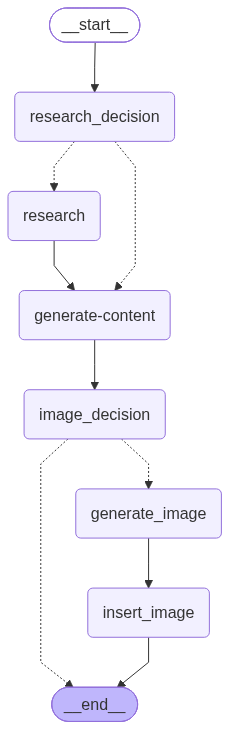

In [17]:
blog

In [35]:
result = blog.invoke({
    "topic": "Explain the self-attention mechanism in deep learning, including how it works, why it is important, and a simple real-world example"
})

print(result["content"].content)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)